In [1]:
## Titanic Classification

## problem statement
- predict if traveller is survived on titanic
- survived is the dependent column

### import required packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### load the data

In [2]:
df = pd.read_csv("C:\\Users\\sainya.vishwakarma\\Python\\SVM\\titanic.csv")
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


### exploratory data analysis

In [3]:
# since the name column are not used to predict the survival of the traveller, lets delete that

df.drop(['name'],axis=1,inplace=True)

In [4]:
# since the home.dest column are not used to predict the survival of the traveller, lets delete that

df.drop(['home.dest'],axis=1,inplace=True)

In [5]:
# get the general info about dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   survived  1309 non-null   int64  
 2   sex       1309 non-null   str    
 3   age       1046 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   str    
 7   fare      1308 non-null   float64
 8   cabin     295 non-null    str    
 9   embarked  1307 non-null   str    
 10  boat      486 non-null    str    
 11  body      121 non-null    float64
dtypes: float64(3), int64(4), str(5)
memory usage: 122.8 KB


In [6]:
# find the missing values for every column
df.isna().sum()

pclass         0
survived       0
sex            0
age          263
sibsp          0
parch          0
ticket         0
fare           1
cabin       1014
embarked       2
boat         823
body        1188
dtype: int64

In [7]:
# since the ticket and fare column are not used to predict the survival of the traveller, lets delete that

df.drop(['ticket','fare'],axis=1,inplace=True)

In [8]:
# to handle the missing values:
# - delete the rows having missing values
    # - when more no of columns in a row is missing, it make sense to delete that row
# - delete the columns having missing values
    # - when most of the values in a column (>50) are missing,its better to delete that column
# - impute/replace the missing values with mean,median or model
    # - standard option use when less no of values are missing in a column 

In [9]:
# since most of the values are missing in cabin,boat and body column so lets delete them
df.drop(['cabin','boat','body'],axis=1,inplace=True)

In [10]:
# since less values in age column are missing lets replace with mean value of age column

df['age'] = df['age'].fillna(df['age'].mean())

In [11]:
mode=df['embarked'].mode()[0]
mode

'S'

In [12]:
# replace the embarked column with mode

df['embarked'] = df['embarked'].fillna(mode)

In [13]:
df.isna().sum()

pclass      0
survived    0
sex         0
age         0
sibsp       0
parch       0
embarked    0
dtype: int64

In [14]:
# convert embarked textual data to numeric

from sklearn.preprocessing import LabelEncoder

# craete the encoder
encoder = LabelEncoder()

#fit the encoder
encoder.fit(df['embarked'])

# transform the values
df['embarked'] = encoder.transform(df['embarked'])


In [15]:
# convert sex column textual data to numeric

from sklearn.preprocessing import LabelEncoder

# craete the encoder
sex_encoder = LabelEncoder()

#fit the encoder
sex_encoder.fit(df['sex'])

# transform the values
df['sex'] = sex_encoder.transform(df['sex'])

In [16]:
sex_encoder.classes_

array(['female', 'male'], dtype=object)

In [17]:
# check if data is imbalanced

df['survived'].value_counts()

survived
0    809
1    500
Name: count, dtype: int64

Text(0.5, 1.0, 'Survival Status')

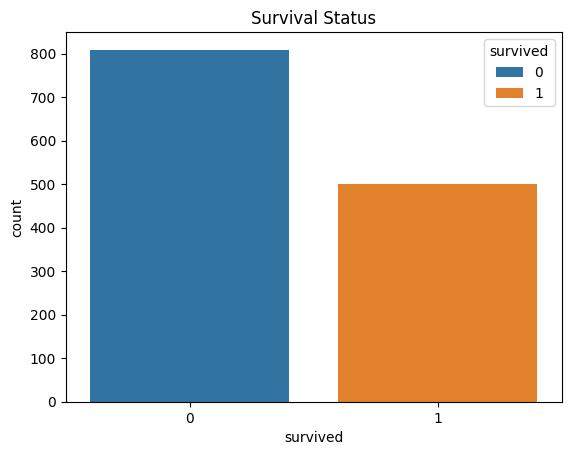

In [18]:
sns.countplot(x='survived',hue='survived',data=df)
plt.title('Survival Status')

Text(0.5, 1.0, 'Gender Status')

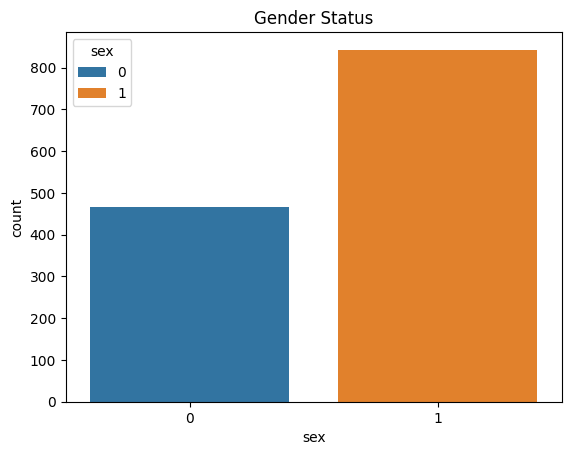

In [19]:
sns.countplot(x='sex',hue='sex',data=df)
plt.title('Gender Status')

Text(0.5, 1.0, 'Survival Status based on sex')

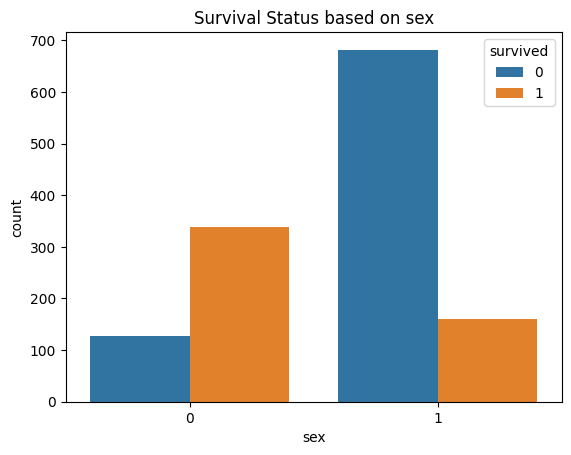

In [20]:
sns.countplot(x='sex',hue='survived',data=df)
plt.title('Survival Status based on sex')

Text(0.5, 1.0, 'Survival Status based on pclass')

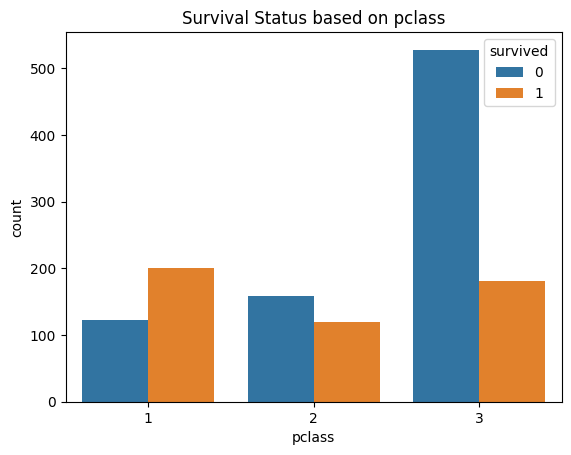

In [21]:
sns.countplot(x='pclass',hue='survived',data=df)
plt.title('Survival Status based on pclass')

Text(0.5, 1.0, 'Survival Status based on age')

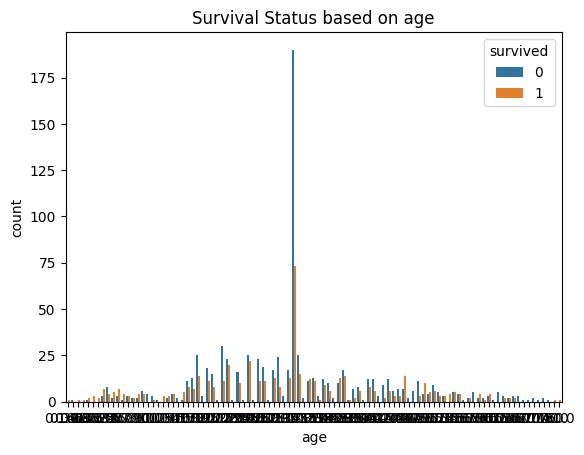

In [22]:
sns.countplot(x='age',hue='survived',data=df)
plt.title('Survival Status based on age')

### perform the correlation analysis

In [23]:
df.corr()['survived'].sort_values()

sex        -0.528693
pclass     -0.312469
embarked   -0.175313
age        -0.050199
sibsp      -0.027825
parch       0.082660
survived    1.000000
Name: survived, dtype: float64

 ### get the statistical info of the dataset

In [24]:
df.describe()

,pclass,survived,sex,age,sibsp,parch,embarked
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000
mean,2.294882,0.381971,0.644003,29.881135,0.498854,0.385027,1.493506
std,0.837836,0.486055,0.478997,12.883199,1.041658,0.865560,0.814244
min,1.000000,0.000000,0.000000,0.166700,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,22.000000,0.000000,0.000000,1.000000
50%,3.000000,0.000000,1.000000,29.881135,0.000000,0.000000,2.000000
75%,3.000000,1.000000,1.000000,35.000000,1.000000,0.000000,2.000000
max,3.000000,1.000000,1.000000,80.000000,8.000000,9.000000,2.000000


### data preparation

In [25]:
# split the data into x and y

x = df.drop(['survived','age','sibsp','parch'],axis=1)
y= df['survived']

In [26]:
# split the data into train and test set

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.7,random_state=42)

### train the models

In [27]:
from sklearn.linear_model import LogisticRegressionCV

def build_logistic_regression_model():
    # create the model
    model = LogisticRegressionCV()

    # fit the model
    model.fit(x_train,y_train)

    return model

In [28]:
from sklearn.naive_bayes import GaussianNB 

def build_naive_bayes_model():
    # create the model
    model = GaussianNB()

    # fit the model
    model.fit(x_train,y_train)

    return model

In [29]:
from sklearn.neighbors import KNeighborsClassifier 

def build_knn_model():
    # create the model
    model = KNeighborsClassifier()

    # fit the model
    model.fit(x_train,y_train)

    return model

In [31]:
from sklearn.svm import SVC 

def build_svc_model():
    # create the model
    model = SVC(kernel = 'linear')

    # fit the model
    model.fit(x_train,y_train)

    return model

# evaluate the models

In [32]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score

def evaluate_model(model_name,model,x,y):
    # predict x
    y_pred = model.predict(x)

    # calculate metrics
    accuracy = accuracy_score(y,y_pred)
    precision = precision_score(y,y_pred)
    recall = recall_score(y,y_pred)
    f1 = f1_score(y,y_pred)

    return model_name,accuracy,precision,recall,f1

### create all the models

In [33]:
model_lr = build_logistic_regression_model()
model_nb = build_naive_bayes_model()
model_knn = build_knn_model()
model_svm = build_svc_model()

C:\Users\sainya.vishwakarma\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
C:\Users\sainya.vishwakarma\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:2137: FutureWarning: The default value of the parameter 'scoring' will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11. To silence this warning, explicitly set the scoring parameter: scoring='neg_log_loss' for the new, scoring='accuracy' or scoring=None for the old default.
  warnings.warn(
C:\Users\sainya.vishwakarma\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:2150: FutureWarning: The fitted attr

In [34]:
# collect all models in a list
models = [
    {"model_name":"Logistic Regression","model":model_lr},
    {"model_name":"Naive Bayes","model":model_nb},
    {"model_name":"KNN","model":model_knn},
    {"model_name":"SVM","model":model_svm}
]

In [35]:
# evaluate all the models

training_metrics = []

for model_info in models:
    training_metrics.append(evaluate_model(model_info['model_name'],model_info['model'],x_train,y_train))

pd.DataFrame(training_metrics,columns = ['Algorithm','Accuracy','Precision','Recall','F1 Score'])

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.799127,0.765343,0.640483,0.697368
1,Naive Bayes,0.766376,0.656836,0.740181,0.696023
2,KNN,0.796943,0.803347,0.580060,0.673684
3,SVM,0.776201,0.694444,0.679758,0.687023


In [37]:
# evaluate all the models

testing_metrics = []

for model_info in models:
    testing_metrics.append(evaluate_model(model_info['model_name'],model_info['model'],x_test,y_test))

pd.DataFrame(testing_metrics,columns = ['Algorithm','Accuracy','Precision','Recall','F1 Score'])

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.768448,0.800000,0.615385,0.695652
1,Naive Bayes,0.776081,0.748466,0.721893,0.734940
2,KNN,0.748092,0.812500,0.538462,0.647687
3,SVM,0.788804,0.802817,0.674556,0.733119
